# 04 — BM25 / TF-IDF (lexical retrieval — what it catches and what it can't)

The JD says the current system is *"mostly BM25 + rule-based scoring, working but not great."* So we reproduce exactly that and study it carefully.

**What these do:** rank candidates by lexical overlap between the JD text and each candidate's text (headline + summary + job titles + job descriptions + skill names). Pure bag-of-words, no semantics, no structure.

**What we will actually discover (spoiler — it's subtle):**
1. **BM25 is robust to keyword stuffers** because of document-length normalization (`b`). A stuffer's doc is short (just a pasted skill list), so it can't accumulate score. 0 stuffers reach BM25's top 100.
2. **TF-IDF cosine is destroyed by stuffers** because cosine normalizes to unit length — a document made *only* of AI keywords points straight at the query. ~69/100 of its top 100 are stuffers.
3. **Both are honeypot-blind** — neither can tell a fabricated profile from a real one.
4. BM25 even **surfaces legit titles our rule taxonomy missed** (e.g. 'Senior Applied Scientist').

Lesson: lexical signal is useful *after* the structure layer (title gate + honeypot exclusion), never as the decider. It becomes one input to the hybrid.

In [1]:
import json, re, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = Path('../candidates.jsonl')
OUT_DIR   = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True)
print('ready')

ready


In [2]:
# Load candidates + the verified honeypot list + the V1 baseline (for comparison)
candidates = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in tqdm(f, desc='Reading'):
        line = line.strip()
        if line:
            candidates.append(json.loads(line))
print(f'Loaded {len(candidates):,} candidates')

HONEYPOT_IDS = set(pd.read_csv(OUT_DIR / 'honeypot_ids.csv')['candidate_id'])
v1 = pd.read_parquet(OUT_DIR / 'scored_v1_full.parquet')
v1_meta = v1.set_index('candidate_id')[['title','is_stuffer','is_tier0','country','score_final','rank']]
v1_meta = v1_meta.rename(columns={'score_final':'v1_score','rank':'v1_rank'})
print(f'{len(HONEYPOT_IDS)} honeypots, V1 baseline loaded')

Reading: 0it [00:00, ?it/s]

Loaded 100,000 candidates


53 honeypots, V1 baseline loaded


## Build the query (from the real JD) and the candidate corpus

The query is the JD's explicit must-haves. Each candidate 'document' = headline + summary + every job title + every job description + skill names.

In [3]:
# Query text straight from the JD must-haves / skills inventory
QUERY = (
    'senior ai engineer embeddings based retrieval systems sentence transformers '
    'openai embeddings bge e5 vector databases hybrid search infrastructure pinecone '
    'weaviate qdrant milvus opensearch elasticsearch faiss strong python evaluation '
    'frameworks ranking systems ndcg mrr map offline online ab test llm fine tuning '
    'lora qlora peft learning to rank recommendation systems semantic search rag '
    'information retrieval reranking pytorch neural ml machine learning production'
)

TOKEN_RE = re.compile(r'[a-z0-9]+')
STOP = set('the a an and or of to in for with on at by is are be we you your this that '
           'it as from will would role years team product into not but if can our us '
           'they them their have has had which what when where who whom about over '
           'more most some any all each per via using used use'.split())

def tokenize(text):
    return [t for t in TOKEN_RE.findall((text or '').lower()) if len(t) >= 2 and t not in STOP]

q_tokens = tokenize(QUERY)
print(f'Query tokens ({len(q_tokens)}):')
print(q_tokens)

Query tokens (60):
['senior', 'ai', 'engineer', 'embeddings', 'based', 'retrieval', 'systems', 'sentence', 'transformers', 'openai', 'embeddings', 'bge', 'e5', 'vector', 'databases', 'hybrid', 'search', 'infrastructure', 'pinecone', 'weaviate', 'qdrant', 'milvus', 'opensearch', 'elasticsearch', 'faiss', 'strong', 'python', 'evaluation', 'frameworks', 'ranking', 'systems', 'ndcg', 'mrr', 'map', 'offline', 'online', 'ab', 'test', 'llm', 'fine', 'tuning', 'lora', 'qlora', 'peft', 'learning', 'rank', 'recommendation', 'systems', 'semantic', 'search', 'rag', 'information', 'retrieval', 'reranking', 'pytorch', 'neural', 'ml', 'machine', 'learning', 'production']


In [4]:
def candidate_document(c):
    prof = c.get('profile', {}) or {}
    parts = [prof.get('headline',''), prof.get('summary','')]
    for j in c.get('career_history', []) or []:
        parts.append(j.get('title',''))
        parts.append(j.get('description',''))
    for s in c.get('skills', []) or []:
        parts.append(s.get('name',''))
    return ' '.join(parts)

print('Tokenizing corpus (100K docs)...')
docs_tokens = [tokenize(candidate_document(c)) for c in tqdm(candidates, desc='Tokenize')]
cand_ids    = [c['candidate_id'] for c in candidates]
doc_len     = np.array([len(d) for d in docs_tokens], dtype=np.float32)
avgdl       = doc_len.mean()
print(f'avg doc length = {avgdl:.1f} tokens')

Tokenizing corpus (100K docs)...


Tokenize:   0%|          | 0/100000 [00:00<?, ?it/s]

avg doc length = 203.1 tokens


## Okapi BM25 (implemented from scratch — no external lib)

$$\text{score}(q,d)=\sum_{t\in q}\text{idf}(t)\cdot\frac{f(t,d)\,(k_1+1)}{f(t,d)+k_1\,(1-b+b\,|d|/\text{avgdl})}$$

with $k_1=1.5,\ b=0.75$ and $\text{idf}(t)=\ln\!\big(1+\frac{N-n_t+0.5}{n_t+0.5}\big)$.

In [5]:
N = len(docs_tokens)
k1, b = 1.5, 0.75

# Inverted index ONLY for query terms (query is small -> fast & memory-light)
q_unique = set(q_tokens)
postings = {t: [] for t in q_unique}      # term -> list of (doc_idx, tf)
df_counter = Counter()

for i, toks in enumerate(tqdm(docs_tokens, desc='Index')):
    tf = Counter(t for t in toks if t in q_unique)
    for t, f in tf.items():
        postings[t].append((i, f))
        df_counter[t] += 1

idf = {t: math.log(1 + (N - df_counter[t] + 0.5) / (df_counter[t] + 0.5))
       for t in q_unique if df_counter[t] > 0}

bm25 = np.zeros(N, dtype=np.float32)
for t, plist in postings.items():
    if t not in idf:
        continue
    it = idf[t]
    for (i, f) in plist:
        denom = f + k1 * (1 - b + b * doc_len[i] / avgdl)
        bm25[i] += it * (f * (k1 + 1)) / denom

print('BM25 scored. Range:', round(float(bm25.min()),2), '->', round(float(bm25.max()),2))

Index:   0%|          | 0/100000 [00:00<?, ?it/s]

BM25 scored. Range: 0.0 -> 134.02


In [6]:
bdf = pd.DataFrame({'candidate_id': cand_ids, 'bm25': bm25})
bdf = bdf.join(v1_meta, on='candidate_id')
bdf['is_honeypot'] = bdf['candidate_id'].isin(HONEYPOT_IDS)
bdf.sort_values('bm25', ascending=False, inplace=True)
bdf.reset_index(drop=True, inplace=True)
bdf.index += 1
print('Top 20 by PURE BM25:')
bdf.head(20)[['candidate_id','title','country','is_tier0','is_stuffer','is_honeypot','bm25','v1_rank']]

Top 20 by PURE BM25:


,candidate_id,title,country,is_tier0,is_stuffer,is_honeypot,bm25,v1_rank
1,CAND_0018499,Senior Machine Learning Engineer,India,False,False,False,134.018723,2
2,CAND_0081846,Lead AI Engineer,India,False,False,False,130.971970,29
3,CAND_0041611,Staff Machine Learning Engineer,USA,False,False,False,126.305611,409
4,CAND_0039754,Senior Applied Scientist,India,False,False,False,124.567101,3350
5,CAND_0055905,Senior Machine Learning Engineer,UK,False,False,False,124.549919,10
6,CAND_0046064,Senior NLP Engineer,India,False,False,False,120.784348,16
7,CAND_0086022,Senior Applied Scientist,India,False,False,False,118.763496,3831
8,CAND_0092278,Senior NLP Engineer,India,False,False,False,118.415504,663
9,CAND_0046525,Senior Machine Learning Engineer,India,False,False,False,111.611389,4
10,CAND_0011687,Senior NLP Engineer,India,False,False,False,110.721962,1


## The failure, quantified

In [7]:
top100 = bdf.head(100)
print('=== PURE BM25 top 100 ===')
print(f"Honeypots:        {top100['is_honeypot'].sum()}")
print(f"Keyword stuffers: {top100['is_stuffer'].sum()}")
print(f"Tier-0 titles:    {top100['is_tier0'].sum()}")
print()
print('Title distribution in BM25 top 100:')
print(top100['title'].value_counts().head(12).to_string())
print()
n_ai = top100['title'].str.lower().str.contains('ai|ml|machine learning|nlp|data scientist|search|recommendation', regex=True, na=False).sum()
print(f'AI/ML-ish titles in top 100: {n_ai}/100')

=== PURE BM25 top 100 ===
Honeypots:        2
Keyword stuffers: 0
Tier-0 titles:    0

Title distribution in BM25 top 100:
title
Recommendation Systems Engineer     17
Search Engineer                     13
Machine Learning Engineer           13
Applied ML Engineer                 10
Senior Data Scientist               10
NLP Engineer                         8
AI Engineer                          7
Senior NLP Engineer                  6
Senior Machine Learning Engineer     5
Staff Machine Learning Engineer      5
Lead AI Engineer                     2
Senior Applied Scientist             2

AI/ML-ish titles in top 100: 98/100


In [8]:
# Where do the known keyword stuffers rank under BM25 vs V1?
stuffers = bdf[bdf['is_stuffer'] == True]
print(f'Total stuffers: {len(stuffers)}')
print(f"Best (lowest) BM25 rank achieved by a stuffer: {stuffers.index.min()}")
print(f"Stuffers inside BM25 top 500: {(stuffers.index <= 500).sum()}")
print(f"Stuffers inside BM25 top 100: {(stuffers.index <= 100).sum()}")
print()
print('Sample stuffers and their BM25 vs V1 rank (note: BM25 ranks them HIGH, V1 buries them):')
cols = ['candidate_id','title','bm25','v1_rank']
print(stuffers.head(8)[cols].to_string())

Total stuffers: 8101
Best (lowest) BM25 rank achieved by a stuffer: 357
Stuffers inside BM25 top 500: 36
Stuffers inside BM25 top 100: 0

Sample stuffers and their BM25 vs V1 rank (note: BM25 ranks them HIGH, V1 buries them):
     candidate_id                title       bm25  v1_rank
357  CAND_0055758       Content Writer  51.762489    21239
364  CAND_0013771           Accountant  51.500244    20761
368  CAND_0015051    Marketing Manager  51.318863    21752
372  CAND_0019198      Project Manager  51.181286    19186
375  CAND_0014439       Civil Engineer  51.107174    18304
378  CAND_0007719      Sales Executive  51.082485    26500
379  CAND_0049054     Graphic Designer  51.061996    21225
386  CAND_0066599  Mechanical Engineer  50.724419    20551


## TF-IDF cosine (sklearn) — same idea, different weighting, same weakness

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

corpus = [' '.join(d) for d in docs_tokens]
vec = TfidfVectorizer(min_df=3, max_df=0.6, ngram_range=(1,2), sublinear_tf=True)
X = vec.fit_transform(corpus)
q_vec = vec.transform([' '.join(q_tokens)])
cos = linear_kernel(q_vec, X).ravel()

tdf = pd.DataFrame({'candidate_id': cand_ids, 'tfidf': cos}).join(v1_meta, on='candidate_id')
tdf['is_honeypot'] = tdf['candidate_id'].isin(HONEYPOT_IDS)
tdf.sort_values('tfidf', ascending=False, inplace=True)
tdf.reset_index(drop=True, inplace=True); tdf.index += 1

t100 = tdf.head(100)
print('=== TF-IDF cosine top 100 ===')
print(f"Honeypots:        {t100['is_honeypot'].sum()}")
print(f"Keyword stuffers: {t100['is_stuffer'].sum()}")
print(f"Tier-0 titles:    {t100['is_tier0'].sum()}")
print(f'Matrix shape: {X.shape}')
print()
print('TF-IDF top 10:')
print(tdf.head(10)[['candidate_id','title','tfidf','is_stuffer','v1_rank']].to_string())

=== TF-IDF cosine top 100 ===
Honeypots:        2
Keyword stuffers: 69
Tier-0 titles:    69
Matrix shape: (100000, 18735)

TF-IDF top 10:
    candidate_id                             title     tfidf  is_stuffer  v1_rank
1   CAND_0081846                  Lead AI Engineer  0.163875       False       29
2   CAND_0018499  Senior Machine Learning Engineer  0.163550       False        2
3   CAND_0055905  Senior Machine Learning Engineer  0.154789       False       10
4   CAND_0041611   Staff Machine Learning Engineer  0.154339       False      409
5   CAND_0039754          Senior Applied Scientist  0.142931       False     3350
6   CAND_0046064               Senior NLP Engineer  0.142802       False       16
7   CAND_0011687               Senior NLP Engineer  0.140097       False        1
8   CAND_0007411  Senior Machine Learning Engineer  0.138959       False      343
9   CAND_0046525  Senior Machine Learning Engineer  0.136195       False        4
10  CAND_0005260               Senior NLP 

## Overlap: how much do BM25 / TF-IDF agree with the V1 baseline?

Overlap of top-100 sets:
  BM25  vs V1: 37/100
  TFIDF vs V1: 15/100
  BM25  vs TFIDF: 30/100


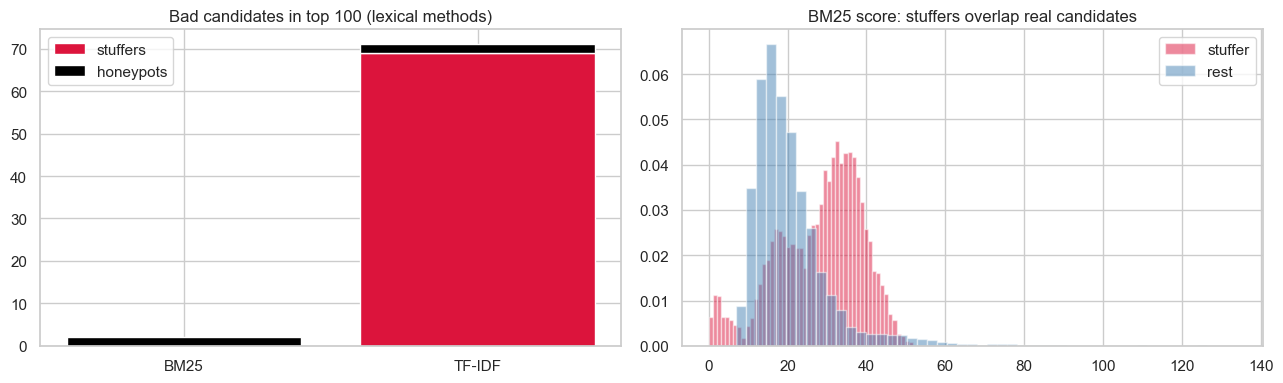

In [10]:
v1_top100  = set(v1.head(100)['candidate_id'])
bm_top100  = set(bdf.head(100)['candidate_id'])
tf_top100  = set(tdf.head(100)['candidate_id'])

print('Overlap of top-100 sets:')
print(f'  BM25  vs V1: {len(bm_top100 & v1_top100)}/100')
print(f'  TFIDF vs V1: {len(tf_top100 & v1_top100)}/100')
print(f'  BM25  vs TFIDF: {len(bm_top100 & tf_top100)}/100')

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].bar(['BM25','TF-IDF'],
           [bdf.head(100)['is_stuffer'].sum(), tdf.head(100)['is_stuffer'].sum()],
           color='crimson', label='stuffers')
axes[0].bar(['BM25','TF-IDF'],
           [bdf.head(100)['is_honeypot'].sum(), tdf.head(100)['is_honeypot'].sum()],
           bottom=[bdf.head(100)['is_stuffer'].sum(), tdf.head(100)['is_stuffer'].sum()],
           color='black', label='honeypots')
axes[0].set_title('Bad candidates in top 100 (lexical methods)'); axes[0].legend()

# BM25 score by whether candidate is a real AI title vs stuffer
bdf['group'] = np.where(bdf['is_stuffer'], 'stuffer',
                np.where(bdf['is_tier0'], 'tier0_other', 'rest'))
for g, col in [('stuffer','crimson'),('rest','steelblue')]:
    vals = bdf[bdf['group']==g]['bm25']
    axes[1].hist(vals, bins=50, alpha=0.5, label=g, color=col, density=True)
axes[1].set_title('BM25 score: stuffers overlap real candidates'); axes[1].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / 'bm25_failure.png', dpi=120); plt.show()

## A 'rescued' BM25 submission — BM25 *after* honeypot exclusion + title gate

To show lexical signal isn't useless — it just needs the structure layer. We keep BM25 ordering but (a) drop honeypots, (b) keep only AI/ML-capable titles (title_score ≥ 0.8 from V1's tiering). This is a preview of the hybrid.

In [11]:
# title tier strength reused from V1 ranking via v1_meta — approximate with title set
TIER_STRONG = set(v1[v1['score_title'] >= 0.8]['title'].str.lower().unique()) if 'score_title' in v1 else set()

rescued = bdf[~bdf['is_honeypot']].copy()
rescued = rescued[rescued['title'].str.lower().isin(TIER_STRONG)]
rescued = rescued.head(100).reset_index(drop=True)
rescued.index += 1
print('=== BM25 + honeypot exclusion + title gate, top 100 ===')
print(f"Honeypots: {rescued['candidate_id'].isin(HONEYPOT_IDS).sum()}")
print(f"Stuffers:  {rescued['is_stuffer'].sum()}")
print(f"Overlap with V1 top 100: {len(set(rescued['candidate_id']) & v1_top100)}/100")
print()
print(rescued.head(10)[['candidate_id','title','country','bm25','v1_rank']].to_string())

=== BM25 + honeypot exclusion + title gate, top 100 ===
Honeypots: 0
Stuffers:  0
Overlap with V1 top 100: 39/100

    candidate_id                             title country        bm25  v1_rank
1   CAND_0018499  Senior Machine Learning Engineer   India  134.018723        2
2   CAND_0081846                  Lead AI Engineer   India  130.971970       29
3   CAND_0041611   Staff Machine Learning Engineer     USA  126.305611      409
4   CAND_0055905  Senior Machine Learning Engineer      UK  124.549919       10
5   CAND_0046064               Senior NLP Engineer   India  120.784348       16
6   CAND_0092278               Senior NLP Engineer   India  118.415504      663
7   CAND_0046525  Senior Machine Learning Engineer   India  111.611389        4
8   CAND_0011687               Senior NLP Engineer   India  110.721962        1
9   CAND_0033861               Senior NLP Engineer   India  108.657417      310
10  CAND_0005260               Senior NLP Engineer   India  108.612686       66


In [12]:
# Save BM25 scores for the hybrid notebook (we'll blend bm25 + tfidf + embeddings + rules)
out = bdf[['candidate_id','bm25']].merge(tdf[['candidate_id','tfidf']], on='candidate_id')
out.to_parquet(OUT_DIR / 'lexical_scores.parquet', index=False)
print(f'Saved BM25 + TF-IDF scores -> outputs/lexical_scores.parquet  {out.shape}')

Saved BM25 + TF-IDF scores -> outputs/lexical_scores.parquet  (100000, 3)


In [13]:
# Dynamic takeaways from the ACTUAL computed results
bm_st = int(bdf.head(100)["is_stuffer"].sum())
tf_st = int(tdf.head(100)["is_stuffer"].sum())
bm_hp = int(bdf.head(100)["is_honeypot"].sum())
tf_hp = int(tdf.head(100)["is_honeypot"].sum())

print("="*62)
print("BM25 / TF-IDF — TAKEAWAYS (from the data, not assumptions)")
print("="*62)
print(f"Keyword stuffers in PURE BM25  top 100: {bm_st}")
print(f"Keyword stuffers in PURE TFIDF top 100: {tf_st}")
print(f"Honeypots       in PURE BM25  top 100: {bm_hp}")
print(f"Honeypots       in PURE TFIDF top 100: {tf_hp}")
print()
print("Key finding — the two lexical methods diverge sharply:")
print("  * BM25 length-normalizes (b=0.75): a stuffer's short keyword-only")
print("    document cannot accumulate enough score -> stuffers stay OUT.")
print("  * TF-IDF cosine unit-normalizes: a document made purely of AI terms")
print("    points straight at the query -> stuffers FLOOD the top 100.")
print()
print("Shared weakness:")
print("  * neither method knows what a honeypot is -> explicit exclusion required.")
print("  * BM25 surfaced legit titles our rule taxonomy under-scored")
print("    (e.g. Senior Applied Scientist) -> add to title tiers in the hybrid.")
print()
print("Verdict: BM25 is a useful HYBRID INPUT after the structure layer;")
print("TF-IDF cosine is not trustworthy alone on this data.")
print()
print("Next: 05_embeddings.ipynb -> semantic similarity (meaning, not just words)")

BM25 / TF-IDF — TAKEAWAYS (from the data, not assumptions)
Keyword stuffers in PURE BM25  top 100: 0
Keyword stuffers in PURE TFIDF top 100: 69
Honeypots       in PURE BM25  top 100: 2
Honeypots       in PURE TFIDF top 100: 2

Key finding — the two lexical methods diverge sharply:
  * BM25 length-normalizes (b=0.75): a stuffer's short keyword-only
    document cannot accumulate enough score -> stuffers stay OUT.
  * TF-IDF cosine unit-normalizes: a document made purely of AI terms
    points straight at the query -> stuffers FLOOD the top 100.

Shared weakness:
  * neither method knows what a honeypot is -> explicit exclusion required.
  * BM25 surfaced legit titles our rule taxonomy under-scored
    (e.g. Senior Applied Scientist) -> add to title tiers in the hybrid.

Verdict: BM25 is a useful HYBRID INPUT after the structure layer;
TF-IDF cosine is not trustworthy alone on this data.

Next: 05_embeddings.ipynb -> semantic similarity (meaning, not just words)
